In [72]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy
import json
import os
from sklearn.model_selection import train_test_split

# from google.colab import drive
# drive.mount('/content/drive', force_remount=False)

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from scipy.stats import spearmanr


# ROOT_DIR = "/content/drive/MyDrive/CompNeuroscience-P1"

ROOT_DIR = "/home/gabriella/Documents/MemorabilityEmotions"

FEATURES_DIR = f"{ROOT_DIR}/lamem_features"
FEATURES_DIR2 = f"{ROOT_DIR}/lamem_features_v2"
FEATURES_DIR3 = f"{ROOT_DIR}/lamem_features_v3"


SAVE_DIR = f"{ROOT_DIR}/memorability_models"
os.makedirs(SAVE_DIR, exist_ok=True)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda



# Inputs

* ViT (768-d): semantic image embedding, trained with language supervision.
* DINO (1024-d): self-supervised visual embedding. Captures texture, shape, composition.
* Emotions (originally one-hot-encoded) (5-d): One-hot-encoding of dominant emotion. 5 categories from the LaMem Dataset: amusement, excitement, awe, contentment, and sad
* Emotion scores (5-d): continuous softmax over 5 CLIP-vs-prompt similarities. How strongly the image aligns with each emotion category.
* Valence/Arousal (2-d) — BLIP-2 answers a scale question in natural language, parsed to a scalar. Rough sentiment/energy estimate.
* SBERT (384-d) — sentence embedding of BLIP-2 caption + emotion description concatenated. Captures free-form semantic + emotional content as text.


In [82]:
df2  = pd.read_parquet(f"{FEATURES_DIR2}/lamem_features_vit_emo.parquet")


df2.columns

Index(['name', 'dataset', 'memscore', 'original_emotion', 'error', 'ec2_label',
       'ec2_label_lamem', 'ec2_residual', 'ec2_amusement', 'ec2_anger',
       'ec2_awe', 'ec2_contentment', 'ec2_disgust', 'ec2_excitement',
       'ec2_fear', 'ec2_sadness', 'ec2_neutral', 'ec2_lamem_amusement',
       'ec2_lamem_awe', 'ec2_lamem_contentment', 'ec2_lamem_excitement',
       'ec2_lamem_sadness'],
      dtype='object')

In [80]:
df = pd.read_parquet(f"{FEATURES_DIR3}/lamem_features_emotions_full.parquet")
df2  = pd.read_parquet(f"{FEATURES_DIR2}/lamem_features_v2_full.parquet")

clip_mat = np.load(f"{FEATURES_DIR}/clip_embeddings.npy")    # (N, 768)
# dino_mat = np.load(f"{FEATURES_DIR}/dino_embeddings.npy")    # (N, 1024)
# sbert_mat    = np.load(f"{FEATURES_DIR}/sbert_embeddings.npy")   # (N, 384)


EMOTIONS = [
    "happiness",
    "sadness",
    "fear",
    "anger",
    "disgust",
    "surprise",
]

memscore = df["memscore"].values.astype(np.float32)

# softmax
emotion_scores = df[[f"emotion_bert_{e}" for e in EMOTIONS]].values.astype(np.float32)  # (N, 5)

emotion_scores_img = df2[[f"ec2_{e}" for e in EMOTIONS]].values.astype(np.float32)  # (N, 5)


print(f"df: {df.shape}")
print(f"clip_mat: {clip_mat.shape}")
# print(f"dino_mat: {dino_mat.shape}")
# print(f"sbert_mat: {sbert_mat.shape}")
print(f"emotion_scores: {emotion_scores.shape}")
print(f"memscore range: [{memscore.min():.3f}, {memscore.max():.3f}]")

KeyError: "['ec2_happiness', 'ec2_surprise'] not in index"

In [42]:
df.columns

Index(['name', 'dataset', 'memscore', 'original_emotion', 'error',
       'emotion_happiness', 'emotion_sadness', 'emotion_fear', 'emotion_anger',
       'emotion_disgust', 'emotion_surprise', 'clip_emotion',
       'clip_emotion_conf', 'caption', 'emotion', 'emotion_go',
       'emotion_bert_happiness', 'emotion_bert_sadness', 'emotion_bert_fear',
       'emotion_bert_anger', 'emotion_bert_disgust', 'emotion_bert_surprise',
       'emotion_bert_entropy', 'emotion_bert_prediction'],
      dtype='object')

In [45]:
entropy_feat = df[["emotion_bert_entropy"]].values.astype(np.float32)
entropy_feat

array([[0.7963787 ],
       [1.3133459 ],
       [1.1391401 ],
       ...,
       [1.5463166 ],
       [0.19040473],
       [0.11038648]], dtype=float32)

In [18]:
all_idx    = np.arange(len(df))
strat_bins = pd.qcut(df["memscore"], q=5, labels=False, duplicates="drop") # stratified

train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.3, random_state=42, stratify=strat_bins
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42,
    stratify=strat_bins.iloc[temp_idx].values
)

print(f"Train : {len(train_idx):>6}  ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_idx):>6}  ({len(val_idx)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_idx):>6}  ({len(test_idx)/len(df)*100:.1f}%)")

Train :  11770  (70.0%)
Val   :   2522  (15.0%)
Test  :   2523  (15.0%)


## 4 · Experiment registry

Each experiment is defined by a name and a list of feature blocks to concatenate. Adding a new experiment requires only a new entry here — training code is shared.

In [46]:
EXPERIMENTS = {
    "A_vit_only": {
        "blocks" : [clip_mat],
        "desc"   : "ViT only (baseline)",
    },
    "C_vit_emo": {
        "blocks" : [clip_mat, emotion_scores],
        "desc"   : "ViT + emotion scores",
    },
    "F_vit_emo_entropy": {
    "blocks": [clip_mat, emotion_scores, entropy_feat],
    "desc": "ViT + emotion scores + entropy"
}
}

for name, cfg in EXPERIMENTS.items():
    cfg["X"]   = np.concatenate(cfg["blocks"], axis=1)
    cfg["dim"]  = cfg["X"].shape[1]

print(f"{'Experiment':<22} {'Input dim':>10}   Description")
print("-" * 80)
for name, cfg in EXPERIMENTS.items():
    print(f"  {name:<20} {cfg['dim']:>10}   {cfg['desc']}")

Experiment              Input dim   Description
--------------------------------------------------------------------------------
  A_vit_only                  768   ViT only (baseline)
  C_vit_emo                   774   ViT + emotion scores
  F_vit_emo_entropy           775   ViT + emotion scores + entropy


In [47]:
class MemorabilityDataset(Dataset):
    def __init__(self, X, scores, indices):
        self.x = torch.tensor(X[indices],      dtype=torch.float32)
        self.y = torch.tensor(scores[indices], dtype=torch.float32)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]


def make_loaders(X, batch_size=512):
    return (
        DataLoader(MemorabilityDataset(X, memscore, train_idx),
                   batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(MemorabilityDataset(X, memscore, val_idx),
                   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(MemorabilityDataset(X, memscore, test_idx),
                   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )


class LinearProbe(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(DEVICE)).cpu())
            targets.append(y)
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mse     = float(np.mean((preds - targets) ** 2))
    r, _    = pearsonr(preds, targets)
    rho, _ = spearmanr(preds, targets)
    return mse, float(r), float(rho)


def train_experiment(
    X,
    lr=1e-3, weight_decay=1e-4,
    max_epochs=200, patience=15, batch_size=512, seed=42,
):
    torch.manual_seed(seed); np.random.seed(seed)

    train_loader, val_loader, test_loader = make_loaders(X, batch_size)
    model     = LinearProbe(X.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    history       = {"train_mse": [], "val_mse": [], "val_r": [], "val_rho": []}
    best_val_mse  = float("inf")
    best_state    = None
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y)

        val_mse, val_r, val_rho= evaluate(model, val_loader)
        history["train_mse"].append(epoch_loss / len(train_loader.dataset))
        history["val_mse"].append(val_mse)
        history["val_r"].append(val_r)
        history["val_rho"].append(val_rho)

        if val_mse < best_val_mse - 1e-6:
            best_val_mse  = val_mse
            best_state    = copy.deepcopy(model.state_dict())
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    test_mse, test_r, test_rho = evaluate(model, test_loader)
    history["test_mse"] = test_mse
    history["test_r"]   = test_r
    history["test_rho"]  = test_rho

    return model, history

In [48]:
print("Experiment Summary")
for name, cfg in EXPERIMENTS.items():
    blocks_desc = []
    if any(np.array_equal(cfg['X'][:, :clip_mat.shape[1]], clip_mat[:, :clip_mat.shape[1]])
           for _ in [1]):
        pass
    print(f"[{name}]  dim={cfg['dim']:>5}  |  {cfg['desc']}")
print()

Experiment Summary
[A_vit_only]  dim=  768  |  ViT only (baseline)
[C_vit_emo]  dim=  774  |  ViT + emotion scores
[F_vit_emo_entropy]  dim=  775  |  ViT + emotion scores + entropy



In [49]:
trained = {}   # name → (model, history)

for name, cfg in EXPERIMENTS.items():
    print(f"{name} | {cfg['desc']}")
    print(f"Input dim: {cfg['dim']}")
    model, history = train_experiment(cfg["X"])
    trained[name] = (model, history)
    print(f"test MSE={history['test_mse']:.5f} | test r={history['test_r']:.4f} | test p={history['test_rho']:.4f}")
    print()


A_vit_only | ViT only (baseline)
Input dim: 768
test MSE=0.00604 | test r=0.6944 | test p=0.6911

C_vit_emo | ViT + emotion scores
Input dim: 774
test MSE=0.00590 | test r=0.7025 | test p=0.6998

F_vit_emo_entropy | ViT + emotion scores + entropy
Input dim: 775
test MSE=0.00589 | test r=0.7034 | test p=0.7004



In [59]:
baseline_mse = trained["A_vit_only"][1]["test_mse"]
baseline_r   = trained["A_vit_only"][1]["test_r"]
baseline_rho = trained["A_vit_only"][1]["test_rho"]

rows = []
for name, cfg in EXPERIMENTS.items():
    _, hist = trained[name]
    rows.append({
        "Experiment" : name,
        "Description": cfg["desc"],
        "Input dim"  : cfg["dim"],
        "Test MSE"   : round(hist["test_mse"], 5),
        "Test r"     : round(hist["test_r"],   4),
        "MSE"       : round(hist["test_mse"] - baseline_mse, 5),
        "r"         : round(hist["test_r"]   - baseline_r,   4),
        "rho"     : round(hist["test_rho"] - baseline_rho, 4),
    })

results_df = pd.DataFrame(rows).sort_values("Test r", ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv(f"{SAVE_DIR}/linear_probe_results.csv", index=False)

       Experiment                    Description  Input dim  Test MSE  Test r      MSE      r    rho
F_vit_emo_entropy ViT + emotion scores + entropy        775   0.00589  0.7034 -0.00015 0.0090 0.0094
        C_vit_emo           ViT + emotion scores        774   0.00590  0.7025 -0.00013 0.0081 0.0087
       A_vit_only            ViT only (baseline)        768   0.00604  0.6944  0.00000 0.0000 0.0000


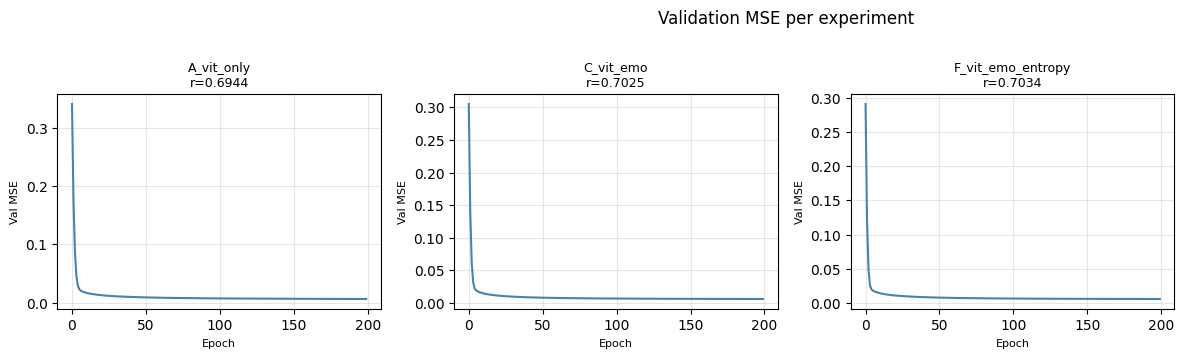

In [60]:
n     = len(EXPERIMENTS)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, (name, cfg) in enumerate(EXPERIMENTS.items()):
    _, hist = trained[name]
    ax = axes[i]
    ax.plot(hist["val_mse"], color="steelblue", label="val MSE")
    ax.set_title(f"{name}\nr={hist['test_r']:.4f}", fontsize=9)
    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("Val MSE", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Validation MSE per experiment", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57073/2529249460.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)


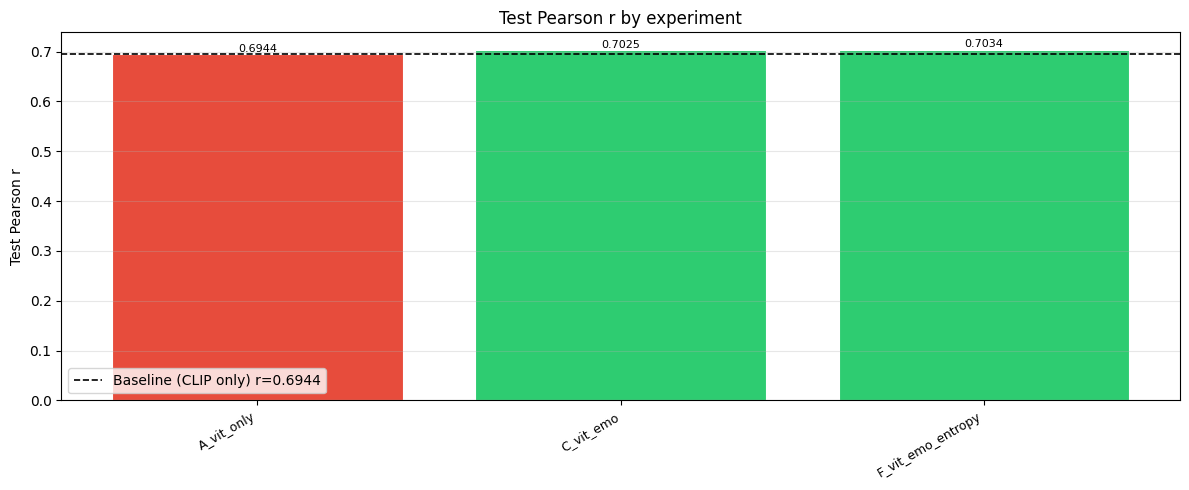

In [61]:
names  = [r["Experiment"]  for r in rows]
r_vals = [r["Test r"]      for r in rows]
colors = ["#2ecc71" if v >= baseline_r else "#e74c3c" for v in r_vals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, r_vals, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(baseline_r, color="black", linewidth=1.2, linestyle="--", label=f"Baseline (CLIP only) r={baseline_r:.4f}")
ax.set_ylabel("Test Pearson r")
ax.set_title("Test Pearson r by experiment")
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, r_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_r_comparison.png", dpi=150)
plt.show()

/tmp/ipykernel_57073/2469633484.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)


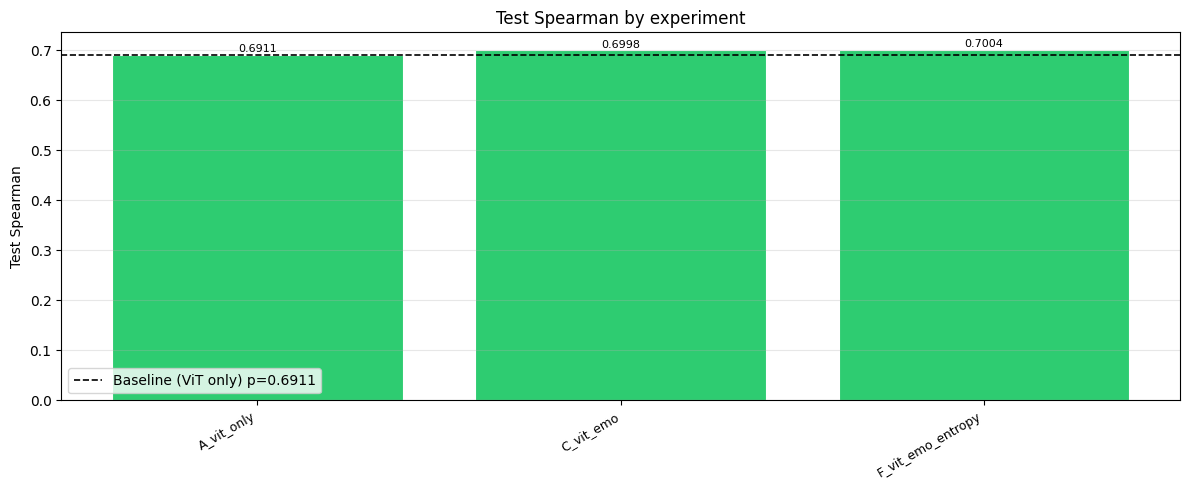

In [62]:
rho_vals = [trained[n][1]["test_rho"] for n in names]
colors_rho = ["#2ecc71" if v >= baseline_rho else "#e74c3c" for v in rho_vals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, rho_vals, color=colors_rho, edgecolor="white", linewidth=0.8)
ax.axhline(baseline_rho, color="black", linewidth=1.2, linestyle="--",
           label=f"Baseline (ViT only) p={baseline_rho:.4f}")
ax.set_ylabel("Test Spearman")
ax.set_title("Test Spearman by experiment")
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, rho_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_rho_comparison.png", dpi=150)
plt.show()

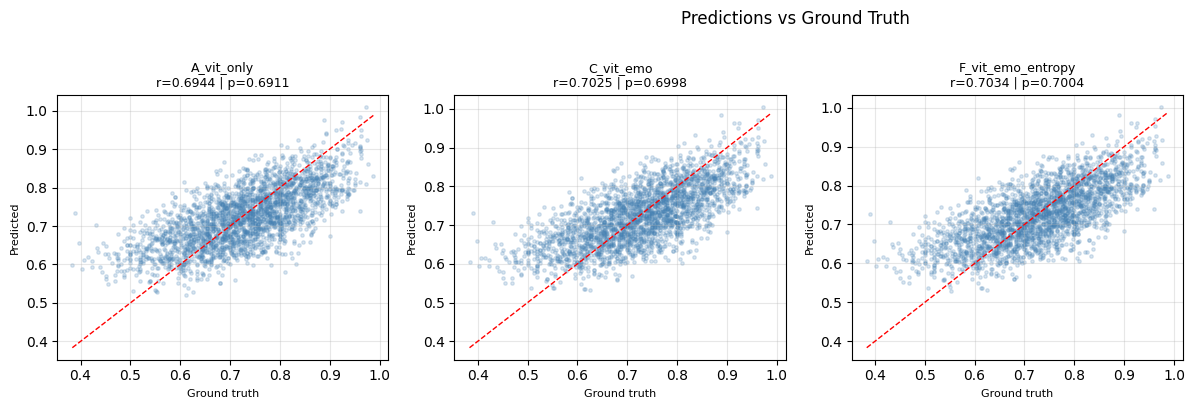

In [63]:
n = len(EXPERIMENTS)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, (name, cfg) in enumerate(EXPERIMENTS.items()):
    model, hist = trained[name]
    _, _, test_loader = make_loaders(cfg["X"])

    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    ax = axes[i]
    ax.scatter(targets, preds, alpha=0.2, s=6, color="steelblue")
    lo, hi = targets.min(), targets.max()
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{name}\nr={hist['test_r']:.4f} | p={hist['test_rho']:.4f}", fontsize=9)
    ax.set_xlabel("Ground truth", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Predictions vs Ground Truth", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [64]:
# change p

In [65]:
summary = {}
for name, (model, hist) in trained.items():
    torch.save(model.state_dict(), f"{SAVE_DIR}/linear_{name}.pt")
    summary[name] = {
        "description": EXPERIMENTS[name]["desc"],
        "input_dim" : EXPERIMENTS[name]["dim"],
        "test_mse" : hist["test_mse"],
        "test_r" : hist["test_r"],
        "delta_r_vs_clip_baseline": hist["test_r"] - baseline_r,
    }


with open(f"{SAVE_DIR}/linear_probe_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Models and summary saved to:", SAVE_DIR)
print()
print("=" * 60)
print("FINAL RANKING (Linear Probe, by Test r)")
print("=" * 60)
for name, v in sorted(summary.items(), key=lambda x: -x[1]["test_r"]):
    delta = v["delta_r_vs_clip_baseline"]
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:<24} r={v['test_r']:.4f}  ({sign}{delta:.4f} vs CLIP baseline)")
print("=" * 60)

Models and summary saved to: /home/gabriella/Documents/MemorabilityEmotions/memorability_models

FINAL RANKING (Linear Probe, by Test r)
  F_vit_emo_entropy        r=0.7034  (+0.0090 vs CLIP baseline)
  C_vit_emo                r=0.7025  (+0.0081 vs CLIP baseline)
  A_vit_only               r=0.6944  (+0.0000 vs CLIP baseline)


In [69]:
from scipy.stats import wilcoxon
import warnings


def get_test_errors(model, X):
    _, _, test_loader = make_loaders(X)
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    return (preds - targets) ** 2

errors = {name: get_test_errors(trained[name][0], cfg["X"])
          for name, cfg in EXPERIMENTS.items()}

N = len(next(iter(errors.values())))


BASELINE_MAP = {
    # ViT-based
    "C_vit_emo":       "A_vit_only",
    "F_vit_emo_entropy":     "A_vit_only",
}

n_tests    = len(BASELINE_MAP)
alpha_corr = 0.05 / n_tests


rows = []
for exp_name, base_name in BASELINE_MAP.items():
    if exp_name not in errors or base_name not in errors:
        continue

    diff = errors[base_name] - errors[exp_name]   # positive = experiment better

    print(f"EXPERIMENT: {exp_name, base_name} | DIFF: {diff} | is_positive: {diff>0}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p = wilcoxon(diff, alternative="greater", zero_method="wilcox")

    z        = (stat - N*(N+1)/4) / np.sqrt(N*(N+1)*(2*N+1)/24)
    # r_effect = abs(z) / np.sqrt(N)

    N_eff = np.sum(diff != 0)
    z = (stat - N_eff*(N_eff+1)/4) / np.sqrt(N_eff*(N_eff+1)*(2*N_eff+1)/24)
    r_effect = abs(z) / np.sqrt(N_eff)

    rows.append({
        "Experiment"    : exp_name,
        "vs. baseline"  : base_name,
        "Description"   : EXPERIMENTS[exp_name]["desc"],
        "Mean MSE"     : round(float(diff.mean()), 6),
        "W"             : round(float(stat), 1),
        "p-value"       : float(p),
        "p (fmt)"       : f"{p:.2e}" if p < 0.001 else f"{p:.4f}",
        "Effect size r" : round(r_effect, 4),
        "Sig."  : "SIGNIFICANT" if p < alpha_corr else "",
        "Direction"     : "better" if diff.mean() > 0 else "worse",
    })


print("\n\n\n\n\n\n")
wilcox_df = pd.DataFrame(rows).sort_values("p-value")

print("WILCOXON SIGNED-RANK TEST — Linear Probe")
print(f"H0: no improvement over backbone  |  Bonferroni alpha = 0.05/{n_tests} = {alpha_corr:.4f}  |  N_test = {N}")
print(wilcox_df[["Experiment","vs. baseline","Mean MSE","W","p (fmt)","Effect size r","Sig.","Direction"]].to_string(index=False))

sig = wilcox_df[wilcox_df["Sig."] == "SIGNIFICANT"]
print(f"Significant improvements (Bonferroni alpha={alpha_corr:.4f})")
if len(sig) == 0:
    print("  None reached significance after Bonferroni correction.")
else:
    for _, row in sig.iterrows():
        print(f"  {row['Experiment']:<22}  p={row['p (fmt)']:<10}  r={row['Effect size r']:.4f}")

wilcox_df.to_csv(f"{SAVE_DIR}/wilcoxon_linear.csv", index=False)


EXPERIMENT: ('C_vit_emo', 'A_vit_only') | DIFF: [ 2.0221516e-04  3.2801554e-04  5.9502479e-04 ...  6.8031810e-04
 -9.0253563e-04  6.9520436e-05] | is_positive: [ True  True  True ...  True False  True]
EXPERIMENT: ('F_vit_emo_entropy', 'A_vit_only') | DIFF: [ 1.4981971e-04  3.1661056e-04  7.7731768e-04 ...  5.5877119e-04
 -7.2824699e-04  1.7482322e-05] | is_positive: [ True  True  True ...  True False  True]







WILCOXON SIGNED-RANK TEST — Linear Probe
H0: no improvement over backbone  |  Bonferroni alpha = 0.05/2 = 0.0250  |  N_test = 2523
       Experiment vs. baseline  Mean MSE         W  p (fmt)  Effect size r        Sig. Direction
F_vit_emo_entropy   A_vit_only  0.000148 1831177.0 3.17e-11         0.1301 SIGNIFICANT    better
        C_vit_emo   A_vit_only  0.000134 1815429.0 5.13e-10         0.1215 SIGNIFICANT    better
Significant improvements (Bonferroni alpha=0.0250)
  F_vit_emo_entropy       p=3.17e-11    r=0.1301
  C_vit_emo               p=5.13e-10    r=0.1215


In [70]:
df = wilcox_df.copy()

df = df.sort_values("p-value")

styled = (
    df[["Experiment","vs. baseline","Mean MSE","p-value","Effect size r","Sig."]]
    .style
    .format({
        "Mean MSE": "{:.6f}",
        "p-value": "{:.2e}",
        "Effect size r": "{:.3f}"
    })

    .background_gradient(subset=["Effect size r"], cmap="Blues")
    .applymap(lambda v: "color: green; font-weight: bold" if v == "SIGNIFICANT" else "",
              subset=["Sig."])
    .set_caption("Wilcoxon Signed-Rank Test Results (Linear Probe)")
)

styled

/tmp/ipykernel_57073/3692422959.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "color: green; font-weight: bold" if v == "SIGNIFICANT" else "",


,Experiment,vs. baseline,Mean MSE,p-value,Effect size r,Sig.
1,F_vit_emo_entropy,A_vit_only,0.000148,3.17e-11,0.130,SIGNIFICANT
0,C_vit_emo,A_vit_only,0.000134,5.13e-10,0.121,SIGNIFICANT
